In [23]:
import numpy as np
import os
from dataset import load_dataset, shuffle_apply_scaler, shuffle_apply_scaler_testing
from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import Adam
from keras.callbacks import ModelCheckpoint,EarlyStopping
from keras.models import load_model
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import math
import tensorflow as tf



def LinearModelTrain(X1_arr_train_shuffle, 
                     X2_arr_train_shuffle, 
                     Y_arr_train_shuffle, 
                     X1_arr_valid_shuffle, 
                     X2_arr_valid_shuffle,
                     Y_arr_valid_shuffle):
    num_encoder_features = 3  # Number of input features
    num_decoder_features = 6
    encoder_seq_len = 900
    decoder_seq_len = 180
    X1_arr_train_shuffle_reshaped = X1_arr_train_shuffle.reshape(-1, encoder_seq_len*num_encoder_features)
    X2_arr_train_shuffle_reshaped = X2_arr_train_shuffle.reshape(-1, decoder_seq_len*num_decoder_features)
    X1_arr_valid_shuffle_reshaped = X1_arr_valid_shuffle.reshape(-1, encoder_seq_len*num_encoder_features)
    X2_arr_valid_shuffle_reshaped = X2_arr_valid_shuffle.reshape(-1, decoder_seq_len*num_decoder_features)

    # Combine the input features
    X_train = np.concatenate((X1_arr_train_shuffle_reshaped, X2_arr_train_shuffle_reshaped), axis=1)
    X_valid = np.concatenate((X1_arr_valid_shuffle_reshaped, X2_arr_valid_shuffle_reshaped), axis=1)

    # Define the model
    model = Sequential()
    model.add(Dense(decoder_seq_len, input_dim=X_train.shape[1], activation='relu'))

    # Compile the model
    model.compile(optimizer=Adam(learning_rate=0.0001), loss='mean_squared_error')
    model.summary()
    
    batch_size = 1024
    epochs = 200
    
    folder_name = '../models/'
    file_name = 'reluModel_1024_Adam'

    cp1 = ModelCheckpoint(
        filepath=folder_name + file_name + '.h5',
        save_best_only=True, verbose=1
    )

    early_stopping = EarlyStopping(patience=10, restore_best_weights=True)
    # early_stopping = EarlyStopping(patience=10, restore_best_weights=True, start_from_epoch=60)
    
    # Train the model
    history=model.fit(X_train, Y_arr_train_shuffle, validation_data=(X_valid, Y_arr_valid_shuffle),
                 epochs=epochs, batch_size=batch_size,
                 callbacks=[cp1,early_stopping])
    return history

def loss_metric_plot(history, save_location, metric_name_str):
    history.history.keys()
    plt.clf()
    plt.plot(history.history['loss'], label='Training ' + metric_name_str)
    plt.plot(history.history['val_' + 'loss'], label='Validation ' + metric_name_str)
    plt.ylabel(metric_name_str)
    plt.xlabel('epoch')
    plt.legend()
    plt.savefig(save_location + '_' + 'MSE' + '.png')
    plt.show()
    return plt.show


def postprocess_perm(arr, Perm_Max, Perm_Min):
    arr=arr*(Perm_Max-Perm_Min)+Perm_Min
    return arr

In [2]:
tf.config.list_physical_devices('GPU')
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
sess = tf.compat.v1.Session(config=tf.compat.v1.ConfigProto(log_device_placement=True))


2025-02-18 11:20:33.679971: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:967] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-02-18 11:20:33.686400: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:967] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-02-18 11:20:33.686425: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:967] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-02-18 11:20:33.687343: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX_VNNI FMA
To enable them in other ope

Num GPUs Available:  1
Device mapping:
/job:localhost/replica:0/task:0/device:GPU:0 -> device: 0, name: NVIDIA GeForce RTX 4090, pci bus id: 0000:01:00.0, compute capability: 8.9



2025-02-18 11:20:34.096026: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:967] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-02-18 11:20:34.096124: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:967] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-02-18 11:20:34.096132: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1700] Could not identify NUMA node of platform GPU id 0, defaulting to 0.  Your kernel may not have been built with NUMA support.
2025-02-18 11:20:34.096150: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:967] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-02-18 11:20:34.096181: I tensorflow/core/common_runtime/gpu/gpu_device.c

In [3]:
df, perm_df, param_df, time_df = load_dataset('../dataset/CombinedDataset.xlsx', '1')
X1_arr_train_shuffle, X2_arr_train_shuffle, Y_arr_train_shuffle, \
X1_arr_valid_shuffle, X2_arr_valid_shuffle, Y_arr_valid_shuffle, \
X1_arr_test_shuffle, X2_arr_test_shuffle, Y_arr_test_shuffle, \
timestamp_test = shuffle_apply_scaler(df, perm_df, param_df, time_df)

Model: "sequential_6"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_6 (Dense)             (None, 180)               680580    
                                                                 
Total params: 680,580
Trainable params: 680,580
Non-trainable params: 0
_________________________________________________________________
Epoch 1/200
188/191 [============================>.] - ETA: 0s - loss: 0.0297
Epoch 1: val_loss improved from inf to 0.02212, saving model to ../models/reluModel_1024_Adam.h5
191/191 [==============================] - 3s 13ms/step - loss: 0.0296 - val_loss: 0.0221
Epoch 2/200
181/191 [===========================>..] - ETA: 0s - loss: 0.0219
Epoch 2: val_loss improved from 0.02212 to 0.01992, saving model to ../models/reluModel_1024_Adam.h5
191/191 [==============================] - 1s 6ms/step - loss: 0.0219 - val_loss: 0.0199
Epoch 3/200
180/191 [======================

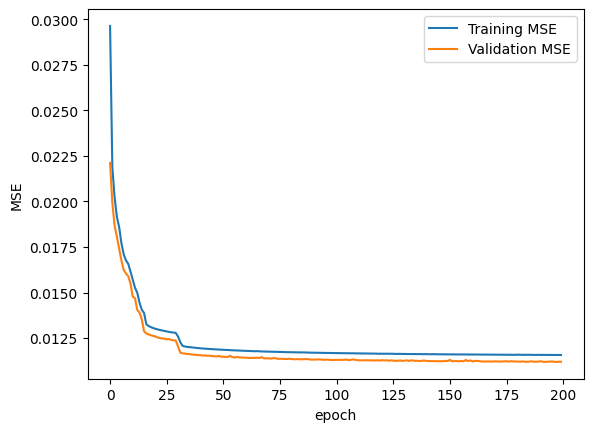

<function matplotlib.pyplot.show(close=None, block=None)>

In [24]:
history = LinearModelTrain(X1_arr_train_shuffle, 
                           X2_arr_train_shuffle, 
                           Y_arr_train_shuffle, 
                           X1_arr_valid_shuffle, 
                           X2_arr_valid_shuffle,
                           Y_arr_valid_shuffle)

loss_metric_plot(history, './plot', 'MSE')


In [8]:
df_testing, perm_df_testing, param_df_testing, time_df_testing = load_dataset('../dataset/CombinedDataset_testing.xlsx','1')
X1_arr_shuffle_testing, X2_arr_shuffle_testing, Y_arr_shuffle_testing = shuffle_apply_scaler_testing(df,df_testing,perm_df_testing,param_df_testing)

In [25]:
file_name = '../models/reluModel_1024_Adam'
filepath=os.path.join(file_name + '.h5')
regressor=load_model(filepath)

In [26]:
num_encoder_features = 3  # Number of input features
num_decoder_features = 6
encoder_seq_len = 900
decoder_seq_len = 180
X1_arr_test_shuffle_reshaped = X1_arr_test_shuffle.reshape(-1, encoder_seq_len*num_encoder_features)
X2_arr_test_shuffle_reshaped = X2_arr_test_shuffle.reshape(-1, decoder_seq_len*num_decoder_features)

X1_arr_test_shuffle_testing_reshaped = X1_arr_shuffle_testing.reshape(-1, encoder_seq_len*num_encoder_features)
X2_arr_test_shuffle_testing_reshaped = X2_arr_shuffle_testing.reshape(-1, decoder_seq_len*num_decoder_features)

    # Combine the input features
X_test = np.concatenate((X1_arr_test_shuffle_reshaped, X2_arr_test_shuffle_reshaped), axis=1)
X_test_testing = np.concatenate((X1_arr_test_shuffle_testing_reshaped, X2_arr_test_shuffle_testing_reshaped), axis=1)

#performance on testing set 1
predictions = regressor.predict(X_test)

perm_max = max(df['Permeability'])
perm_min = min(df['Permeability'])

predictions_flat = postprocess_perm(predictions.flatten(), perm_max, perm_min)
Y_arr_test_shuffle_flat = postprocess_perm(Y_arr_test_shuffle.flatten(), perm_max, perm_min)

mape = abs((predictions_flat-Y_arr_test_shuffle_flat)/Y_arr_test_shuffle_flat)
r2 = r2_score(Y_arr_test_shuffle_flat, predictions_flat)
mse = ((predictions_flat - Y_arr_test_shuffle_flat)**2)
mae = abs(predictions_flat - Y_arr_test_shuffle_flat)

print('Testing set 1')
print("MAPE: "+str(mape.mean()))
print("r2: "+str(r2))
print("MAE: "+str(mae.mean()))
print("MSE: "+str(mse.mean()))
print("RMSE: "+str(math.sqrt(mse.mean())))

#performance on testing set 2
predictions = regressor.predict(X_test_testing)

predictions_flat = postprocess_perm(predictions.flatten(), perm_max, perm_min)
Y_arr_test_shuffle_flat = postprocess_perm(Y_arr_shuffle_testing.flatten(), perm_max, perm_min)

mape = abs((predictions_flat-Y_arr_test_shuffle_flat)/Y_arr_test_shuffle_flat)
r2 = r2_score(Y_arr_test_shuffle_flat, predictions_flat)
mse=((predictions_flat-Y_arr_test_shuffle_flat)**2)
mae=abs(predictions_flat-Y_arr_test_shuffle_flat)

print('Testing set 2')
print("MAPE: "+str(mape.mean()))
print("r2: "+str(r2))
print("MAE: "+ str(mae.mean()))
print("MSE: "+str(mse.mean()))
print("RMSE: "+str(math.sqrt(mse.mean())))

1114/1114 [==============================] - 1s 789us/step
Testing set 1
MAPE: 0.19202717579501624
r2: -1.2141932390571513
MAE: 12.36063146605284
MSE: 555.7936731917714
RMSE: 23.575276736271228
643/643 [==============================] - 1s 915us/step
Testing set 2
MAPE: 0.19551472613996201
r2: -0.7927561831339371
MAE: 9.874774545028588
MSE: 311.23155984186906
RMSE: 17.641756143929353
